In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
data_path = '/content/drive/MyDrive/ids_project/data/raw/cic_ids_2017/'

all_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"Found {len(all_files)} CSV files:")
for f in all_files:
    print(f"  - {f}")

df_list = []
for file in all_files:
    temp = pd.read_csv(os.path.join(data_path, file),
                       encoding='utf-8', low_memory=False)

    # tag the day from filename
    day_tag = file.replace('.csv', '').strip()
    temp['day'] = day_tag

    print(f"Loaded: {file} — shape: {temp.shape} — tagged as: '{day_tag}'")
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")
print(f"\nDay tags added:")
print(df['day'].value_counts())

Found 8 CSV files:
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  - Wednesday-workingHours.pcap_ISCX.csv
  - Tuesday-WorkingHours.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  - Friday-WorkingHours-Morning.pcap_ISCX.csv
  - Monday-WorkingHours.pcap_ISCX.csv
Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv — shape: (288602, 80) — tagged as: 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX'
Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv — shape: (170366, 80) — tagged as: 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX'
Loaded: Wednesday-workingHours.pcap_ISCX.csv — shape: (692703, 80) — tagged as: 'Wednesday-workingHours.pcap_ISCX'
Loaded: Tuesday-WorkingHours.pcap_ISCX.csv — shape: (445909, 80) — tagged as: 'Tuesday-WorkingHours.pcap_ISCX'
Loaded: Friday-WorkingHours-Afternoon-DDos.pca

In [ ]:
print("=== First 5 rows ===")
display(df.head())

print("\n=== Dataset Info ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n=== Column Names ===")
for i, col in enumerate(df.columns):
    print(f"  {i+1:02d}. {col}")

=== First 5 rows ===


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,day
0,22,166,1,1,0,0,0,0,0.0,0.0,...,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN,Thursday-WorkingHours-Afternoon-Infilteration....
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN,Thursday-WorkingHours-Afternoon-Infilteration....
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN,Thursday-WorkingHours-Afternoon-Infilteration....
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN,Thursday-WorkingHours-Afternoon-Infilteration....
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN,Thursday-WorkingHours-Afternoon-Infilteration....



=== Dataset Info ===
Rows: 2,830,743
Columns: 80

=== Column Names ===
  01.  Destination Port
  02.  Flow Duration
  03.  Total Fwd Packets
  04.  Total Backward Packets
  05. Total Length of Fwd Packets
  06.  Total Length of Bwd Packets
  07.  Fwd Packet Length Max
  08.  Fwd Packet Length Min
  09.  Fwd Packet Length Mean
  10.  Fwd Packet Length Std
  11. Bwd Packet Length Max
  12.  Bwd Packet Length Min
  13.  Bwd Packet Length Mean
  14.  Bwd Packet Length Std
  15. Flow Bytes/s
  16.  Flow Packets/s
  17.  Flow IAT Mean
  18.  Flow IAT Std
  19.  Flow IAT Max
  20.  Flow IAT Min
  21. Fwd IAT Total
  22.  Fwd IAT Mean
  23.  Fwd IAT Std
  24.  Fwd IAT Max
  25.  Fwd IAT Min
  26. Bwd IAT Total
  27.  Bwd IAT Mean
  28.  Bwd IAT Std
  29.  Bwd IAT Max
  30.  Bwd IAT Min
  31. Fwd PSH Flags
  32.  Bwd PSH Flags
  33.  Fwd URG Flags
  34.  Bwd URG Flags
  35.  Fwd Header Length
  36.  Bwd Header Length
  37. Fwd Packets/s
  38.  Bwd Packets/s
  39.  Min Packet Length
  40.  Max 

In [ ]:
# strip whitespace from all column names
df.columns = df.columns.str.strip()

# check the target column
print("Unique values in Label column:")
print(df['Label'].value_counts())

Unique values in Label column:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
# fix using regex wildcard — matches any character in place of the special char
df['Label'] = df['Label'].str.strip()

# replace using regex — .+ matches any character(s) between "Attack" and the attack name
import re

def fix_label(label):
    if 'Web Attack' in label and 'Brute Force' in label:
        return 'Web Attack - Brute Force'
    elif 'Web Attack' in label and 'XSS' in label:
        return 'Web Attack - XSS'
    elif 'Web Attack' in label and 'Sql Injection' in label:
        return 'Web Attack - Sql Injection'
    return label

df['Label'] = df['Label'].apply(fix_label)

# verify fix
web_labels = df[df['Label'].str.contains('Web Attack', na=False)]['Label'].unique()
print("Web Attack labels after fix:")
for l in web_labels:
    print(f"  {repr(l)}")

print("\nFull label distribution after fix:")
print(df['Label'].value_counts())

Web Attack labels after fix:
  'Web Attack - Brute Force'
  'Web Attack - XSS'
  'Web Attack - Sql Injection'

Full label distribution after fix:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


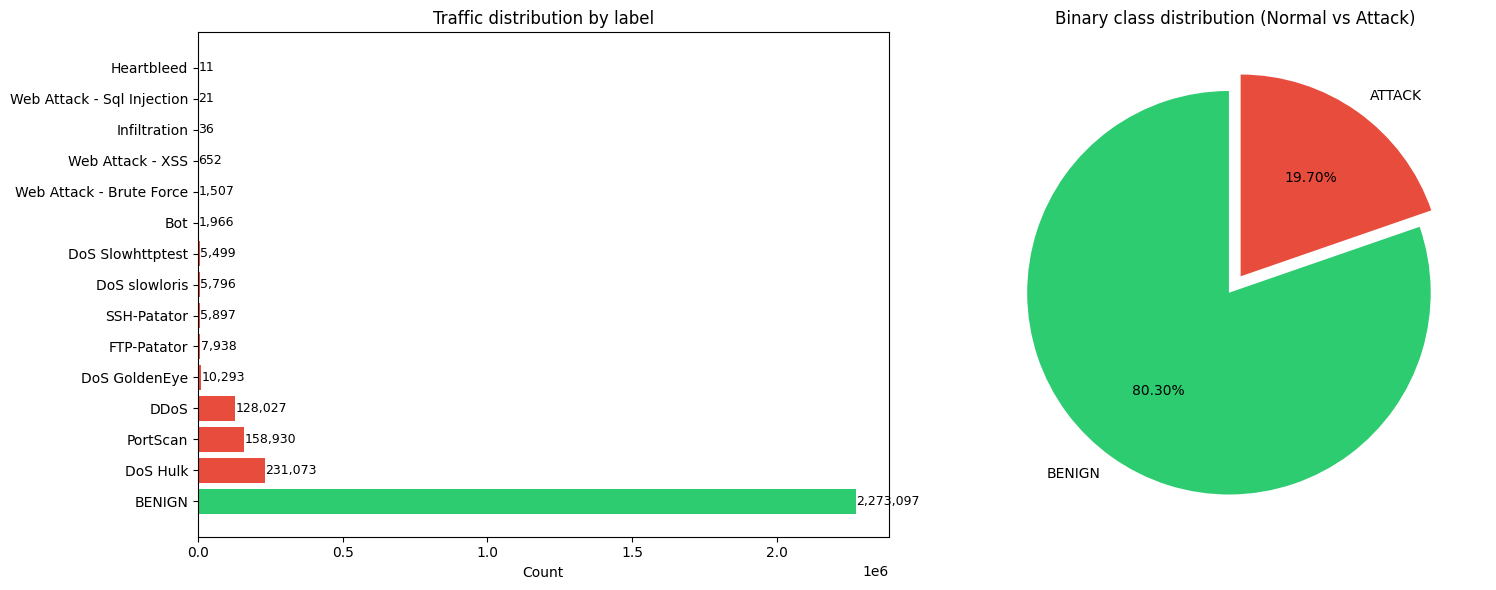


Imbalance ratio: 4.1:1
BENIGN:  2,273,097 (80.3%)
ATTACK:  557,646 (19.7%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Full label breakdown (all attack types) ---
label_counts = df['Label'].value_counts()
colors = ['#2ecc71' if l == 'BENIGN' else '#e74c3c' for l in label_counts.index]

axes[0].barh(label_counts.index, label_counts.values, color=colors)
axes[0].set_xlabel('Count')
axes[0].set_title('Traffic distribution by label')
for i, (val, name) in enumerate(zip(label_counts.values, label_counts.index)):
    axes[0].text(val + 1000, i, f'{val:,}', va='center', fontsize=9)

# --- Plot 2: Binary distribution (Normal vs Attack) ---
df['Binary_Label'] = df['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK')
binary_counts = df['Binary_Label'].value_counts()

axes[1].pie(
    binary_counts.values,
    labels=binary_counts.index,
    autopct='%1.2f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0.05, 0.05)
)
axes[1].set_title('Binary class distribution (Normal vs Attack)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ids_project/report/class_distribution.png', dpi=150)
plt.show()

# Print imbalance ratio
majority = binary_counts.max()
minority = binary_counts.min()
print(f"\nImbalance ratio: {majority/minority:.1f}:1")
print(f"BENIGN:  {binary_counts['BENIGN']:,} ({binary_counts['BENIGN']/len(df)*100:.1f}%)")
print(f"ATTACK:  {binary_counts['ATTACK']:,} ({binary_counts['ATTACK']/len(df)*100:.1f}%)")

In [ ]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing if len(missing) > 0 else "No missing values found")

print("\n=== Infinite Values ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_cols = inf_counts[inf_counts > 0]
print(inf_cols if len(inf_cols) > 0 else "No infinite values found")

=== Missing Values ===
Flow Bytes/s    1358
dtype: int64

=== Infinite Values ===
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


In [ ]:
print("=== Descriptive Statistics (first 10 numeric columns) ===")
display(df.select_dtypes(include=[np.number]).describe().T.head(10))

=== Descriptive Statistics (first 10 numeric columns) ===


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,4.430000e+02,6.553500e+04
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3.204828e+06,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.000000e+00,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.0,0.0,123.0,4.820000e+02,6.554530e+08
Fwd Packet Length Max,2830743.0,2.075999e+02,7.171848e+02,0.0,6.0,37.0,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2830743.0,1.871366e+01,6.033935e+01,0.0,0.0,2.0,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,2830743.0,5.820194e+01,1.860912e+02,0.0,6.0,34.0,5.000000e+01,5.940857e+03
Fwd Packet Length Std,2830743.0,6.891013e+01,2.811871e+02,0.0,0.0,0.0,2.616295e+01,7.125597e+03


In [ ]:
# check how many rows are affected total
inf_mask = np.isinf(df[numeric_cols]).any(axis=1)
nan_mask = df.isnull().any(axis=1)
affected = (inf_mask | nan_mask).sum()
print(f"Total affected rows: {affected:,} out of {len(df):,} ({affected/len(df)*100:.3f}%)")

Total affected rows: 2,867 out of 2,830,743 (0.101%)


In [ ]:
# replace inf with NaN first, then drop all NaN rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Rows after cleaning: {len(df):,}")
print(f"Rows dropped: {2_830_743 - len(df):,}")

Rows after cleaning: 2,827,876
Rows dropped: 2,867


In [ ]:
# these are identifiers, not features — will cause data leakage if kept
cols_to_drop = [
    'Fwd Header Length.1'  # exact duplicate of Fwd Header Length
]

# drop only if they exist in dataframe
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Columns after dropping useless ones: {df.shape[1]}")
print(f"Dropped: {cols_to_drop}")

Columns after dropping useless ones: 80
Dropped: ['Fwd Header Length.1']


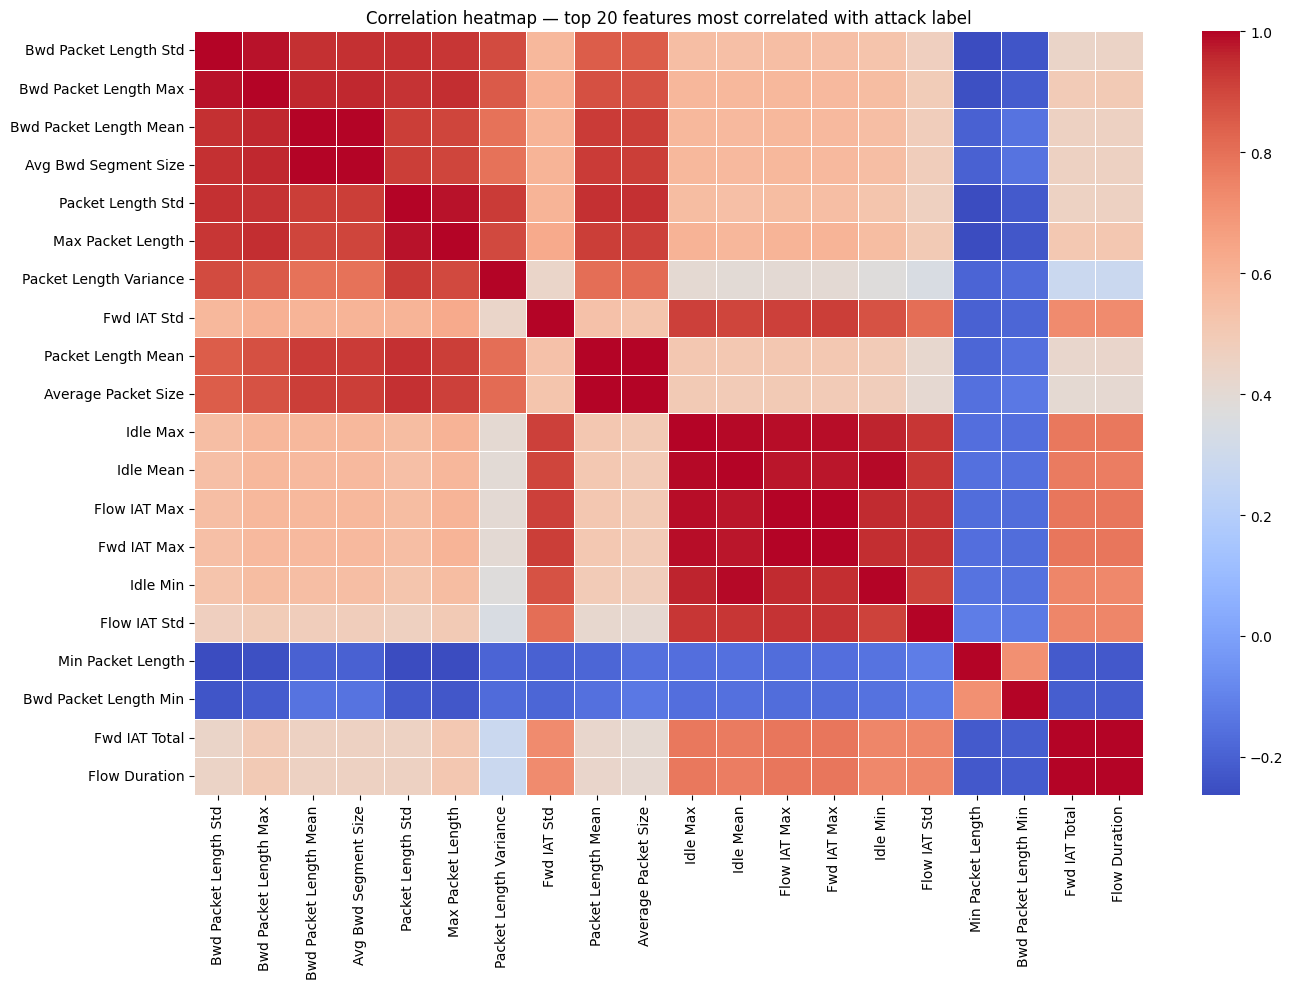

In [ ]:
# use only numeric columns, drop ID-like columns
drop_cols = ['Flow ID', 'Source IP', 'Source Port',
             'Destination IP', 'Destination Port', 'Timestamp']
drop_cols = [c for c in drop_cols if c in df.columns]

numeric_df = df.drop(columns=drop_cols).select_dtypes(include=[np.number])

# compute correlation with binary label
df['Binary_Label_num'] = (df['Binary_Label'] == 'ATTACK').astype(int)
correlations = numeric_df.corrwith(df['Binary_Label_num']).abs().sort_values(ascending=False)

top_features = correlations.head(20).index.tolist()

plt.figure(figsize=(14, 10))
corr_matrix = numeric_df[top_features].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5,
            xticklabels=True, yticklabels=True)
plt.title('Correlation heatmap — top 20 features most correlated with attack label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ids_project/report/correlation_heatmap.png', dpi=150)
plt.show()

In [ ]:
print("=== Top 20 features most correlated with ATTACK label ===")
for i, (feat, corr) in enumerate(correlations.head(20).items()):
    print(f"  {i+1:02d}. {feat:<45} {corr:.4f}")

=== Top 20 features most correlated with ATTACK label ===
  01. Bwd Packet Length Std                         0.5109
  02. Bwd Packet Length Max                         0.4927
  03. Bwd Packet Length Mean                        0.4849
  04. Avg Bwd Segment Size                          0.4849
  05. Packet Length Std                             0.4709
  06. Max Packet Length                             0.4547
  07. Packet Length Variance                        0.4544
  08. Fwd IAT Std                                   0.4233
  09. Packet Length Mean                            0.4148
  10. Average Packet Size                           0.4137
  11. Idle Max                                      0.3948
  12. Idle Mean                                     0.3910
  13. Flow IAT Max                                  0.3892
  14. Fwd IAT Max                                   0.3892
  15. Idle Min                                      0.3812
  16. Flow IAT Std                                  0.337

In [ ]:
# save the label-encoded version for next phase
df['Binary_Label_num'] = (df['Binary_Label'] == 'ATTACK').astype(int)

print("=== Phase 1 Summary ===")
print(f"Total records:       {len(df):,}")
print(f"Total features:      {df.shape[1]}")
print(f"BENIGN records:      {(df['Binary_Label']=='BENIGN').sum():,}")
print(f"ATTACK records:      {(df['Binary_Label']=='ATTACK').sum():,}")
print(f"Imbalance ratio:     {majority/minority:.1f}:1")
print(f"Attack types found:  {df['Label'].nunique() - 1}")
print("\nPhase 1 complete! Move to Phase 2 — Preprocessing")

=== Phase 1 Summary ===
Total records:       2,827,876
Total features:      81
BENIGN records:      2,271,320
ATTACK records:      556,556
Imbalance ratio:     4.1:1
Attack types found:  14

Phase 1 complete! Move to Phase 2 — Preprocessing


In [ ]:
# apply IQR outlier removal on numeric columns only
# we cap outliers (clip) rather than drop — safer for large datasets

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Binary_Label']]

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# clip values to IQR bounds instead of dropping rows
df[numeric_cols] = df[numeric_cols].clip(lower=lower, upper=upper, axis=1)

print("Outlier clipping complete using IQR method")
print(f"Dataset shape after outlier handling: {df.shape}")

Outlier clipping complete using IQR method
Dataset shape after outlier handling: (2827876, 81)


In [ ]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes:,}")

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates — all good!")

Duplicate rows found: 507,387
Duplicates removed. New shape: (2320489, 81)


In [ ]:
# save day column separately BEFORE dropping from features
day_col = df['day'].reset_index(drop=True)

# drop label columns AND day from features
X = df.drop(columns=['Label', 'Binary_Label', 'day'])
y = df['Binary_Label'].reset_index(drop=True)

# save day tags for Phase 7 (concept drift)
save_path = '/content/drive/MyDrive/ids_project/data/processed/'
os.makedirs(save_path, exist_ok=True)
day_col.to_csv(save_path + 'day_tags.csv', index=False)

print(f"Features (X) shape:  {X.shape}")
print(f"Target  (y) shape:   {y.shape}")
print(f"Day tags saved:      {day_col.value_counts().to_string()}")

Features (X) shape:  (2320489, 78)
Target  (y) shape:   (2320489,)
Day tags saved:      day
Wednesday-workingHours.pcap_ISCX                           582561
Monday-WorkingHours.pcap_ISCX                              454150
Tuesday-WorkingHours.pcap_ISCX                             386923
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX               220937
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX    212226
Friday-WorkingHours-Morning.pcap_ISCX                      175392
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX         155308
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX           132992


In [ ]:
# check what Binary_Label currently contains
print("Current Binary_Label unique values:", df['Binary_Label'].unique()[:5])

# re-encode properly as integers
df['Binary_Label'] = (df['Label'].str.strip() != 'BENIGN').astype(int)

# verify
print("After fix:", df['Binary_Label'].unique())
print("Distribution:")
print(df['Binary_Label'].value_counts())

Current Binary_Label unique values: ['BENIGN' 'ATTACK']
After fix: [0 1]
Distribution:
Binary_Label
0    1970197
1     350292
Name: count, dtype: int64


In [ ]:
save_path = '/content/drive/MyDrive/ids_project/data/processed/'
os.makedirs(save_path, exist_ok=True)
df.to_csv(save_path + 'cleaned_df.csv', index=False)
print(f"Saved! Shape: {df.shape}")

Saved! Shape: (2320489, 81)


In [ ]:
from sklearn.model_selection import train_test_split

# also keep day tags aligned with splits for Phase 7
X_with_day = X.copy()
X_with_day['day'] = day_col.values
X_with_day['Binary_Label'] = y.values

# concept drift split — Thursday & Friday go to drift test set
drift_days = ['Thursday-WorkingHours.pcap_ISCX',
              'Friday-WorkingHours.pcap_ISCX',
              'Friday-WorkingHours-2.pcap_ISCX']  # some datasets have 2 Friday files

drift_mask = X_with_day['day'].str.contains('Thursday|Friday', case=False, na=False)

drift_df   = X_with_day[drift_mask].copy()
main_df    = X_with_day[~drift_mask].copy()

print(f"Main pool (Mon-Wed):     {len(main_df):,} rows")
print(f"Drift test (Thu-Fri):    {len(drift_df):,} rows")

# now split main pool into 70/15/15
X_main = main_df.drop(columns=['day', 'Binary_Label'])
y_main = main_df['Binary_Label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X_main, y_main,
    test_size=0.30,
    random_state=42,
    stratify=y_main
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


Main pool (Mon-Wed):     1,423,634 rows
Drift test (Thu-Fri):    896,855 rows


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib

save_path  = '/content/drive/MyDrive/ids_project/data/processed/'
model_path = '/content/drive/MyDrive/ids_project/models/'
os.makedirs(model_path, exist_ok=True)

# reload cleaned df
df = pd.read_csv(save_path + 'cleaned_df.csv', low_memory=False)

print(f"Reloaded! Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[-5:]}")  # show last 5 cols to confirm day + Binary_Label are there
print(f"Binary_Label unique: {df['Binary_Label'].unique()}")

Mounted at /content/drive
Reloaded! Shape: (2320489, 81)
Columns: ['Idle Min', 'Label', 'day', 'Binary_Label', 'Binary_Label_num']
Binary_Label unique: [0 1]


In [ ]:
day_col = df['day'].reset_index(drop=True)
X = df.drop(columns=['Label', 'Binary_Label', 'day'])
y = df['Binary_Label'].reset_index(drop=True)

print(f"X shape:    {X.shape}")
print(f"y shape:    {y.shape}")
print(f"Day tags:\n{day_col.value_counts()}")

X shape:    (2320489, 78)
y shape:    (2320489,)
Day tags:
day
Wednesday-workingHours.pcap_ISCX                           582561
Monday-WorkingHours.pcap_ISCX                              454150
Tuesday-WorkingHours.pcap_ISCX                             386923
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX               220937
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX    212226
Friday-WorkingHours-Morning.pcap_ISCX                      175392
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX         155308
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX           132992
Name: count, dtype: int64


In [ ]:
X_with_day = X.copy()
X_with_day['day'] = day_col.values
X_with_day['Binary_Label'] = y.values

drift_mask = X_with_day['day'].str.contains('Thursday|Friday', case=False, na=False)
drift_df   = X_with_day[drift_mask].copy()
main_df    = X_with_day[~drift_mask].copy()

X_main = main_df.drop(columns=['day', 'Binary_Label'])
y_main = main_df['Binary_Label'].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_main, y_main,
    test_size=0.30,
    random_state=42,
    stratify=y_main
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

X_drift = drift_df.drop(columns=['day', 'Binary_Label'])
y_drift = drift_df['Binary_Label'].astype(int)

# fast print using numpy
print(f"Train:      {X_train.shape[0]:,} rows | Attack: {y_train.values.sum():,} ({y_train.values.mean()*100:.1f}%)")
print(f"Validation: {X_val.shape[0]:,} rows | Attack: {y_val.values.sum():,} ({y_val.values.mean()*100:.1f}%)")
print(f"Test:       {X_test.shape[0]:,} rows | Attack: {y_test.values.sum():,} ({y_test.values.mean()*100:.1f}%)")
print(f"Drift:      {X_drift.shape[0]:,} rows | Attack: {y_drift.values.sum():,} ({y_drift.values.mean()*100:.1f}%)")

Train:      996,543 rows | Attack: 142,002 (14.2%)
Validation: 213,545 rows | Attack: 30,429 (14.2%)
Test:       213,546 rows | Attack: 30,429 (14.2%)
Drift:      896,855 rows | Attack: 147,432 (16.4%)


In [ ]:
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_main.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=X_main.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_main.columns)
X_drift_scaled = pd.DataFrame(scaler.transform(X_drift),     columns=X_main.columns)

print("Scaling done! Saving to Drive...")

X_train_scaled.to_csv(save_path + 'X_train.csv', index=False)
X_val_scaled.to_csv(save_path   + 'X_val.csv',   index=False)
X_test_scaled.to_csv(save_path  + 'X_test.csv',  index=False)
X_drift_scaled.to_csv(save_path + 'X_drift.csv', index=False)

y_train.to_csv(save_path + 'y_train.csv', index=False)
y_val.to_csv(save_path   + 'y_val.csv',   index=False)
y_test.to_csv(save_path  + 'y_test.csv',  index=False)
y_drift.to_csv(save_path + 'y_drift.csv', index=False)

joblib.dump(scaler, model_path + 'scaler.pkl')

print("All saved to Drive!")
print(f"  X_train, X_val, X_test, X_drift")
print(f"  y_train, y_val, y_test, y_drift")
print(f"  scaler.pkl")
print(f"\nPhase 2 complete! Ready for Phase 3 — Feature Selection")

Scaling done! Saving to Drive...
All saved to Drive!
  X_train, X_val, X_test, X_drift
  y_train, y_val, y_test, y_drift
  scaler.pkl

Phase 2 complete! Ready for Phase 3 — Feature Selection
